Aperçu des données :
   Age   Salary  SpendingScore  Gender  Response
0   25  50000.0           60.0    Male         1
1   30  60000.0           70.0  Female         1
2   22  40000.0           50.0  Female         0
3   35  80000.0           80.0    Male         1
4   40  90000.0           30.0    Male         0

Informations générales :
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Age            10 non-null     int64  
 1   Salary         9 non-null      float64
 2   SpendingScore  9 non-null      float64
 3   Gender         10 non-null     object 
 4   Response       10 non-null     int64  
dtypes: float64(2), int64(2), object(1)
memory usage: 532.0+ bytes
None

Statistiques :
             Age         Salary  SpendingScore   Response
count  10.000000       9.000000       9.000000  10.000000
mean   32.400000   69111.111111      57.777778

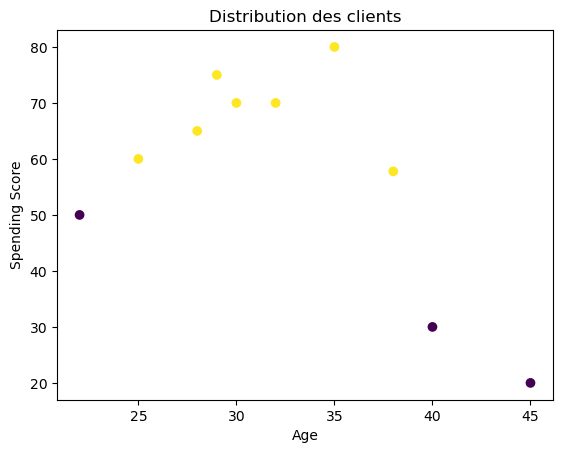

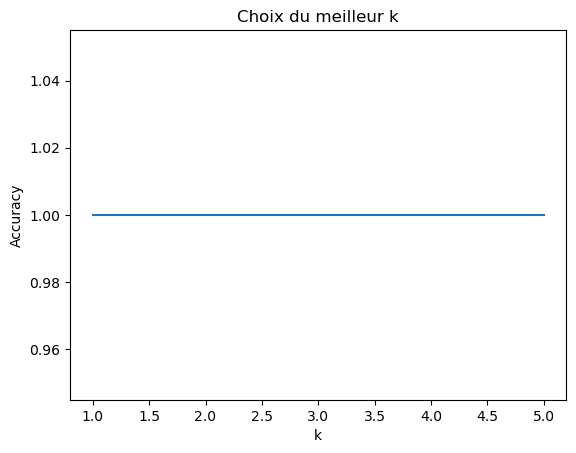

In [3]:
# 1. IMPORTATION DES LIBRAIRIES

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LinearRegression
from sklearn.metrics import accuracy_score, mean_squared_error

# 2. CHARGEMENT DES DONNÉES

df = pd.read_csv("marketing_data.csv")

print("Aperçu des données :")
print(df.head())

# 3. EXPLORATION DES DONNÉES

print("\nInformations générales :")
print(df.info())

print("\nStatistiques :")
print(df.describe())

print("\nValeurs manquantes :")
print(df.isnull().sum())

# 4. NETTOYAGE DES DONNÉES

# remplacer valeurs manquantes
df['Salary'] = df['Salary'].fillna(df['Salary'].mean())
df['SpendingScore'] = df['SpendingScore'].fillna(df['SpendingScore'].mean())

# convertir Gender en numérique
df['Gender'] = df['Gender'].map({'Male': 0, 'Female': 1})

print("\nAprès nettoyage :")
print(df.isnull().sum())

# 5. SÉPARATION X / y

X = df.drop('Response', axis=1)
y = df['Response']

# division train/test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# 6. MODÈLE KNN

knn = KNeighborsClassifier(n_neighbors=3)

knn.fit(X_train, y_train)

y_pred_knn = knn.predict(X_test)

accuracy = accuracy_score(y_test, y_pred_knn)
print("\nAccuracy KNN :", accuracy)


# 7. RÉGRESSION LINÉAIRE

lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)
mse = mean_squared_error(y_test, y_pred_lr)
print("Erreur (MSE) Régression :", mse)


# 8. VISUALISATION

plt.scatter(df['Age'], df['SpendingScore'], c=df['Response'])
plt.xlabel("Age")
plt.ylabel("Spending Score")
plt.title("Distribution des clients")
plt.show()

# 9. BONUS : TEST DE PLUSIEURS k

k_values = range(1, 6)
scores = []

for k in k_values:
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    scores.append(accuracy_score(y_test, y_pred))

plt.plot(k_values, scores)
plt.xlabel("k")
plt.ylabel("Accuracy")
plt.title("Choix du meilleur k")
plt.show()